Consider the problem of training a Deep Q-learning Network (DQN) for a vacuum
cleaner in a grid environment.\
Our environment is an m × n grid in which there are p < m · n dirty squares.\
Target m, n and p values are m, n = 15, p = 10.
We have a vacuum cleaner starting at a corner position (0, 0) that needs to clean the given dirty squares in as short of a path as possible.\
The vacuum cleaner can move only in the directions of N,S,E,W and it has to collect all the trash and the job is done when the last dirty tile has been cleaned.

In [ ]:
# import necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pygame
import numpy as np
import sys
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [ ]:
# set rewards and penalties
illegal_penalty = -0.01
step_penalty = -0.01
trash_reward = 1.0

In [ ]:
# define the environment
class Environment:
#
# Constructor
#==========================================\
  def __init__(self, m, n, p, seed=123):
    self.m = m # columns
    self.n = n # rows

    self.p = p # trash count

    self.seed = seed # RNG seed

    self.size = m * n
    self.grid_shape = (m, n)
    self.grid = np.zeros(self.grid_shape)

    # Rendering attributes
    self.CELL_SIZE = 60
    self.screen = None
    self.clock = None

    self.init_graphics()

    self.reset()
#==========================================/
#

#
# Initialize the pygame environment
#================================================================================================\
  def init_graphics(self):
    if self.screen is None:
      pygame.init()
      self.screen = pygame.display.set_mode((self.m * self.CELL_SIZE, self.n * self.CELL_SIZE))
      pygame.display.set_caption("Trash collection simulation")
      self.clock = pygame.time.Clock()
#================================================================================================/
#

#
# Cleanup the pygame environment
#===========================\
  def exit_graphics(self):
    pygame.quit()
#===========================/
#

#
# Renders the environment state
#==========================================================================================================================\
  def render(self, fps=10):

    # Event handling
    for event in pygame.event.get():
      if event.type == pygame.QUIT:
        self.exit_graphics()

    # Drawing logic
    self.screen.fill((255, 255, 255))

    # Draw Grid and Trash
    for r in range(self.m):
      for c in range(self.n):
        rect = pygame.Rect(r * self.CELL_SIZE, c * self.CELL_SIZE, self.CELL_SIZE, self.CELL_SIZE)
        pygame.draw.rect(self.screen, (200, 200, 200), rect, 1) # Grid lines

        # Draw Trash (Brown Circle)
        if self.grid[r, c] == 1:
          pygame.draw.circle(self.screen, (139, 69, 19), rect.center, self.CELL_SIZE // 4)

    # Draw Agent (Blue Square)
    ax, ay = self.agent
    agent_rect = pygame.Rect(ax * self.CELL_SIZE + 5, ay * self.CELL_SIZE + 5, self.CELL_SIZE - 10, self.CELL_SIZE - 10)
    pygame.draw.rect(self.screen, (0, 120, 255), agent_rect)

    # Update Display and Clock
    pygame.display.flip()
    self.clock.tick(fps)
#==========================================================================================================================/
#

#
# Reset the agent (position in top left corner)
#=========================\
  def reset_agent(self):
    self.agent = (0, 0)
#=========================/
#

#
# Reset the grid
#==========================================================================\
  def reset_grid(self):
    self.grid = np.zeros((self.m, self.n))

    rng = np.random.default_rng(self.seed)

    # pick p unique indices for trash
    indices = rng.choice(range(1, self.size), size=self.p, replace=False)

    # convert flat -> 2D indices
    rows, cols = np.unravel_index(indices, self.grid.shape)

    # fill the trash positions with value 1
    self.grid[rows, cols] = 1
#==========================================================================/
#

#
# Reset the environment
#==============================\
  def reset(self):
    self.reset_agent()
    self.reset_grid()
    self.trash_count = self.p
    return self.get_state()
#==============================/

#
# Get the grid + agent states as a single grid with two channels
#==========================================================\
  def get_state(self):
    # Create the agent grid
    agent_channel = np.zeros(self.grid_shape)
    agent_channel[self.agent] = 1

    return np.stack([self.grid, agent_channel], axis=-1)
#==========================================================/
#

#
# Define a step
#=====================================================================\
  def step(self, action):

    # get the agent coordinates
    x, y = self.agent

    # set the initial reward equal to the step penalty
    reward = step_penalty

    # move the agent
    actions = [
        ( 0, -1), # N
        ( 0,  1), # S
        ( 1,  0), # E
        (-1,  0)  # W
    ]
    action_x, action_y = actions[action]
    new_x = x + action_x
    new_y = y + action_y

    # if the move is illegal, apply the illegal move penalty
    # if the move is legal, perform the move
    if new_x >= self.m or new_x < 0 or new_y >= self.n or new_y < 0:
      reward += illegal_penalty
    else:
      x = new_x
      y = new_y

    # update the agents position
    self.agent = (x, y)

    # if the agent reaches trash, remove the trash and reward the agent
    if self.grid[self.agent] == 1:
      self.grid[self.agent] = 0
      self.trash_count -= 1
      reward += trash_reward

    # determine the if agent is done cleaning
    done = self.trash_count == 0

    # return the state, reward, and the done variable
    return self.get_state(), reward, done
#=====================================================================/
#

In [ ]:
# initialize the environment
m = 10
n = 10
p = 7
environment = Environment(m, n, p)

I will be implementing the Breakout DQN architecture for this assignment.

In [ ]:
# Configuration paramaters for the whole setup
seed = 42
gamma = 0.99      # Discount factor for past rewards
epsilon = 1.0     # Epsilon greedy parameter
epsilon_min = 0.1 # Minimum epsilon greedy parameter
epsilon_max = 1.0 # Maximum epsilon greedy parameter

# Rate at which to reduce chance of random action being taken
epsilon_interval = (epsilon_max - epsilon_min)

# Size of batch taken from replay buffer
batch_size = 32
max_steps_per_episode = 200
num_actions = 4

In [ ]:
# Define the network
def create_DQN():

  # define the input shape
  input_shape = (m, n, 2,)
  inputs = layers.Input(shape=input_shape)

  # convolutional layers
  layer1 = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
  layer2 = layers.Conv2D(64, 3, activation="relu", padding="same")(layer1)
  layer3 = layers.MaxPooling2D()(layer2)
  layer4 = layers.Flatten()(layer3)

  # dense layers
  layer5 = layers.Dense(128, activation="relu")(layer4)
  layer6 = layers.Dense(64, activation="relu")(layer5)

  # output layer
  action = layers.Dense(num_actions, activation="linear")(layer6)

  return keras.Model(inputs=inputs, outputs=action)

In [ ]:
# Online model for predicting Q-values used to make actions.
model = create_DQN()

# Target model for predicting future rewards.
# Target model weights get updated every 1000 steps
model_target = create_DQN()

# Dispaly model summaries
model.summary()
model_target.summary()

# Define the Adam optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.0025, clipnorm=1.0)

# Experience replay buffers
action_history = []
state_history = []
state_next_history = []
rewards_history = []
done_history = []
episode_reward_history = []
running_reward = 0
episode_count = 0
frame_count = 0

# Number of frames to take random action and observe output
epsilon_random_frames = 2000

# Number of frames for exploration
epsilon_greedy_frames = 50000

# Maximum replay length
max_memory_length = 100000

# How often to update the target network
update_target_network = 500

# Using huber loss for stability
loss_function = keras.losses.Huber()

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 10, 10, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 10, 10, 64)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,988 (3.30 MB)

 Trainable params: 865,988 (3.30 MB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 10, 10, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 10, 10, 64)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,988 (3.30 MB)

 Trainable params: 865,988 (3.30 MB)

 Non-trainable params: 0 (0.00 B)

Now I define the training cycle.

In [ ]:
# exploration
def explore(frame_count, epsilon):
  # Use epislon-greedy for exploration
  if frame_count < epsilon_random_frames or epsilon > np.random.rand(1)[0]:
    # Take random action
    action = np.random.choice(num_actions)
  else:
    # Predict action Q-values
    # from environment state
    state_tensor = tf.expand_dims(state, axis=0)
    action_probs = model(state_tensor, training=False)
    # Take the best action
    action = tf.argmax(action_probs[0]).numpy()
  return action

In [ ]:
# learn from past actions and update
def learn(action_history, state_history, state_next_history, done_history, rewards_history, state):
  if len(done_history) > batch_size:

    # Get indices of samples for replay buffers
    indices = np.random.choice(range(len(done_history)), size=batch_size)

    # Using list comprehension to sample from replay buffer
    state_sample = np.array([state_history[i] for i in indices])
    state_next_sample = np.array([state_next_history[i] for i in indices])

    rewards_sample = [rewards_history[i] for i in indices]
    action_sample = [action_history[i] for i in indices]
    done_sample = tf.convert_to_tensor(
        [float(done_history[i]) for i in indices]
    )

    # Build the updated Q-values for the sampled future states
    # use the target model for stability
    future_rewards = model_target(state_next_sample, training=False)
    # Q value = reward + discount factor * expected future reward
    updated_q_values = rewards_sample + gamma * tf.reduce_max(
        future_rewards, axis=1
    )

    # If final frame set the last value to -1
    updated_q_values = updated_q_values * (1 - done_sample) - done_sample

    # Create a mask so we only calculate loss on the updated Q-values
    masks = tf.one_hot(action_sample, num_actions)

    with tf.GradientTape() as tape:
      # Train the model on the states and updated Q-values
      q_values = model(state_sample, verbose=0)

      # Apply the masks to the Q-values to get the Q-value for action taken
      q_action = tf.reduce_sum(tf.multiply(q_values, masks), axis=1)
      # Calculate loss between new Q-value and old Q-value
      loss = loss_function(updated_q_values, q_action)

    # Backpropagation
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [ ]:
# define an episode
def episode(max_steps, frame_count, epsilon, episode_reward, state, steps):
  for step in range(1, max_steps):
    frame_count += 1
    steps += 1

    # explore and choose an action
    action = explore(frame_count, epsilon)

    # Decay probability of taking random action
    epsilon -= epsilon_interval / epsilon_greedy_frames
    epsilon = max(epsilon, epsilon_min)

    # Apply the sampled action in our environment
    state_next, reward, done = environment.step(action)

    # Render and wait
    environment.render()

    # Update the episode reward
    episode_reward += reward

    # Save actions and states in replay buffer
    action_history.append(action)
    state_history.append(state)
    state_next_history.append(state_next)
    done_history.append(done)
    rewards_history.append(reward)
    state = state_next

    # learn from past actions
    learn(
      action_history,
      state_history,
      state_next_history,
      done_history,
      rewards_history,
      state
    )

    if frame_count % update_target_network == 0:
      # Update the target network
      model_target.set_weights(model.get_weights())

      # print details
      template = "current average reward: {:.2f} for episode {}, frame count {}"
      print(template.format(running_reward, episode_count, frame_count))

    # Limit the state and reward history
    if len(rewards_history) > max_memory_length:
      del rewards_history[:1]
      del state_history[:1]
      del state_next_history[:1]
      del action_history[:1]
      del done_history[:1]

    if done:
      return frame_count, epsilon, episode_reward, state, True, steps
  return frame_count, epsilon, episode_reward, state, False, steps

In [ ]:
# print out the environment before cleaning
print(environment.grid)


# Training loop
while True: # Run until solved
  state = environment.reset()
  episode_reward = 0
  steps = 0

  # run an episode
  frame_count, epsilon, episode_reward, state, done, steps = episode(max_steps_per_episode, frame_count, epsilon, episode_reward, state, steps)

  # Update running reward to check condition for solving
  episode_reward_history.append(episode_reward)
  print(episode_reward)
  if len(episode_reward_history) > 100:
    del episode_reward_history[:1]
  running_reward = np.mean(episode_reward_history)

  episode_count += 1

  if done:  # Condition to consider the task solved
    print("Solved on episode {}!".format(episode_count))
    break

# print out the timestep variable to represent steps
print("Solved after ", steps, " steps.")

# print out the environment after cleaning
print(environment.grid)

[[0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
2.860000000000017
-0.15000000000000163
current average reward: 1.36 for episode 2, frame count 500
1.8299999999999983
2.9500000000000153
0.6499999999999981
current average reward: 1.63 for episode 5, frame count 1000
-0.3600000000000015
0.7299999999999984
current average reward: 1.22 for episode 7, frame count 1500
1.9000000000000137
-2.329999999999995
2.7900000000000285
current average reward: 1.09 for episode 10, frame count 2000
1.8500000000000087
1.8700000000000256
current average reward: 1.22 for episode 12, frame count 2500
1.5799999999999987
1.8200000000000012
2.8300000000000307
current average reward: 1.39 for episode 15, frame count 3000
1.559999999999

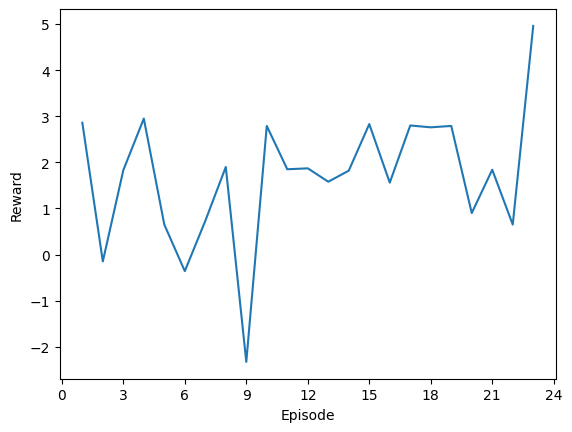

In [ ]:
# plot the data reward over episode
fig, ax = plt.subplots()
ax.plot(range(1,len(episode_reward_history)+1), episode_reward_history)
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()